### **Business Problem:**
LoanTap is a digital lending platform focused on providing customized loan products tailored for millennials, especially salaried professionals and business owners. The company differentiates itself by offering instant and flexible loans with consumer-friendly terms, aiming to bring innovation to the traditionally rigid loan sector.
LoanTap offers four primary financial instruments:

- Personal Loan
- EMI-Free Loan
- Personal Overdraft
- Advance Salary Loan

The Data Science Team is developing an underwriting layer to assess the creditworthiness of individuals and MSMEs (Micro, Small, and Medium Enterprises).

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings


### 1. Basic Metrics:

In [98]:
df_lt = pd.read_csv('C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\CaseStudy\\LoanTap\\logistic_regression.csv')
df_lt.head()


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [99]:
df_lt.shape

(396030, 27)

In [100]:
df_lt.info()  ## details of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [101]:
df_lt.describe(include='all')

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
count,396030.000000,396030,396030.000000,396030.000000,396030,396030,373103,377729,396030,3.960300e+05,...,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,396030,396030,358235.000000,395495.000000,396030
unique,NaN,2,NaN,NaN,7,35,173105,11,6,NaN,...,NaN,NaN,NaN,NaN,NaN,2,3,NaN,NaN,393700
top,NaN,36 months,NaN,NaN,B,B3,Teacher,10+ years,MORTGAGE,NaN,...,NaN,NaN,NaN,NaN,NaN,f,INDIVIDUAL,NaN,NaN,USS Smith\r\nFPO AP 70466
freq,NaN,302005,NaN,NaN,116018,26655,4389,126041,198348,NaN,...,NaN,NaN,NaN,NaN,NaN,238066,395319,NaN,NaN,8
mean,14113.888089,NaN,13.639400,431.849698,NaN,NaN,NaN,NaN,NaN,7.420318e+04,...,11.311153,0.178191,1.584454e+04,53.791749,25.414744,NaN,NaN,1.813991,0.121648,NaN
std,8357.441341,NaN,4.472157,250.727790,NaN,NaN,NaN,NaN,NaN,6.163762e+04,...,5.137649,0.530671,2.059184e+04,24.452193,11.886991,NaN,NaN,2.147930,0.356174,NaN
min,500.000000,NaN,5.320000,16.080000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,...,0.000000,0.000000,0.000000e+00,0.000000,2.000000,NaN,NaN,0.000000,0.000000,NaN
25%,8000.000000,NaN,10.490000,250.330000,NaN,NaN,NaN,NaN,NaN,4.500000e+04,...,8.000000,0.000000,6.025000e+03,35.800000,17.000000,NaN,NaN,0.000000,0.000000,NaN
50%,12000.000000,NaN,13.330000,375.430000,NaN,NaN,NaN,NaN,NaN,6.400000e+04,...,10.000000,0.000000,1.118100e+04,54.800000,24.000000,NaN,NaN,1.000000,0.000000,NaN
75%,20000.000000,NaN,16.490000,567.300000,NaN,NaN,NaN,NaN,NaN,9.000000e+04,...,14.000000,0.000000,1.962000e+04,72.900000,32.000000,NaN,NaN,3.000000,0.000000,NaN


In [102]:
df_lt.isna() ##Check for the missing values

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396026,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396027,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396028,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


----------------------------------------------------------------------------------------------------------------
### **Univariate Analysis**

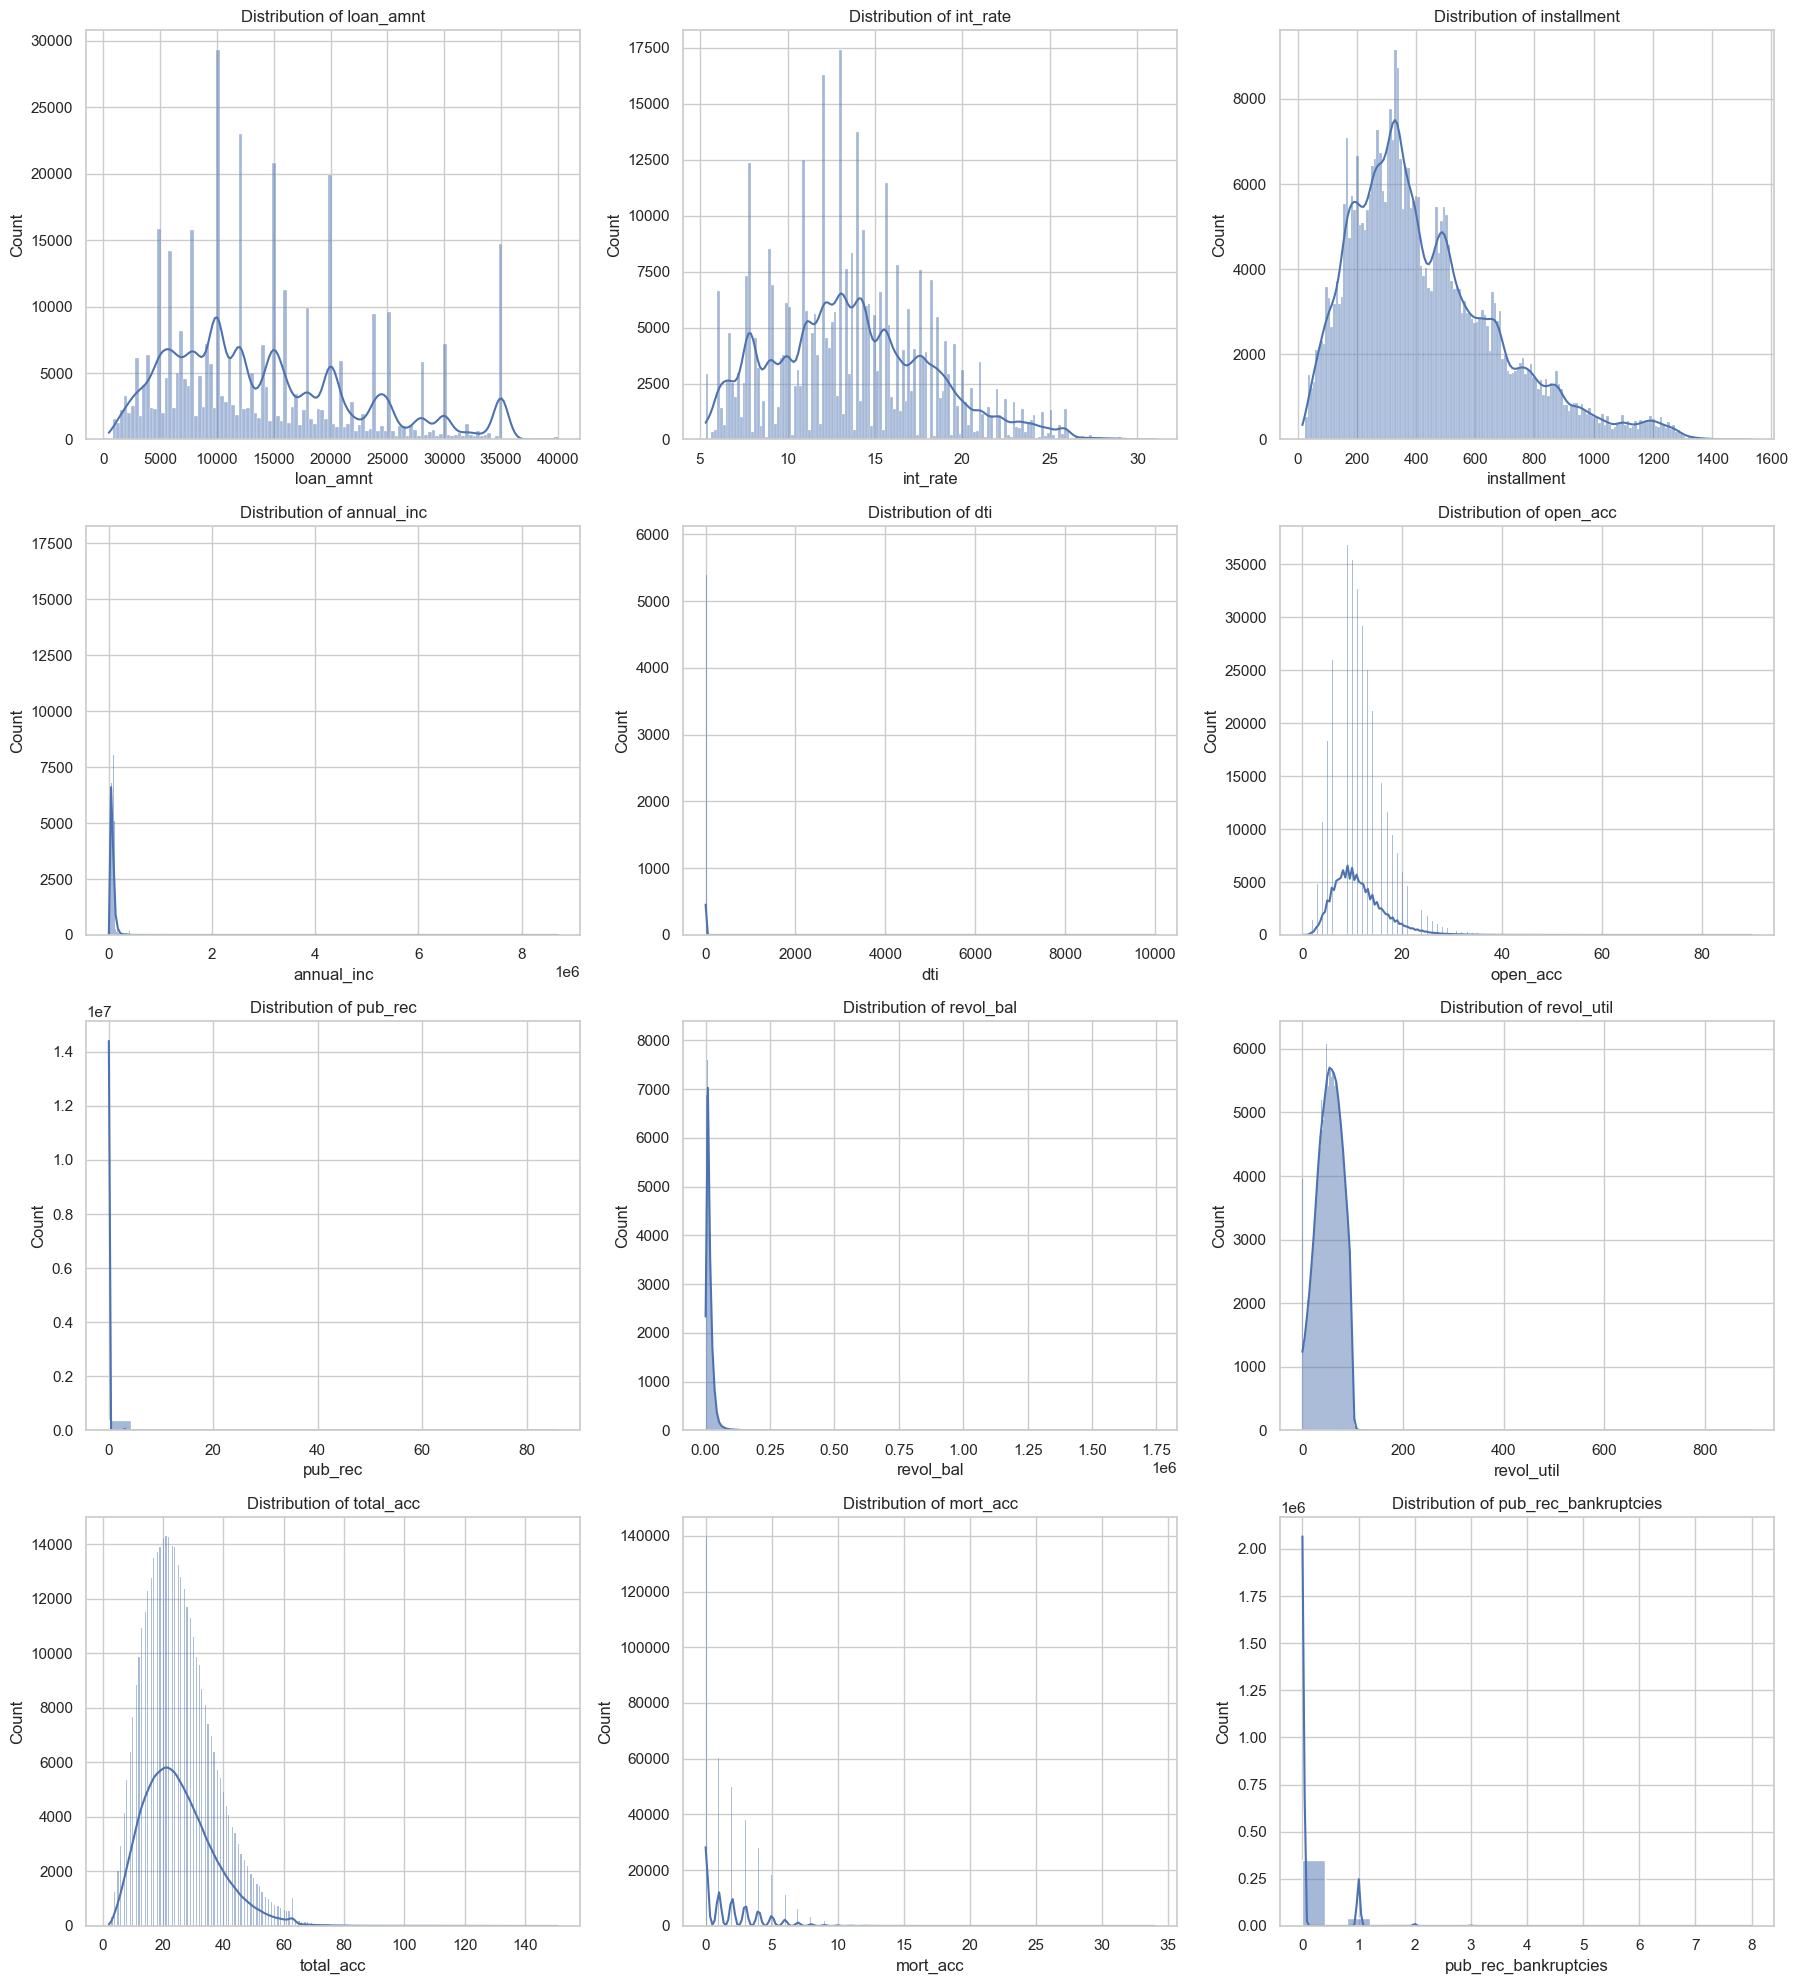

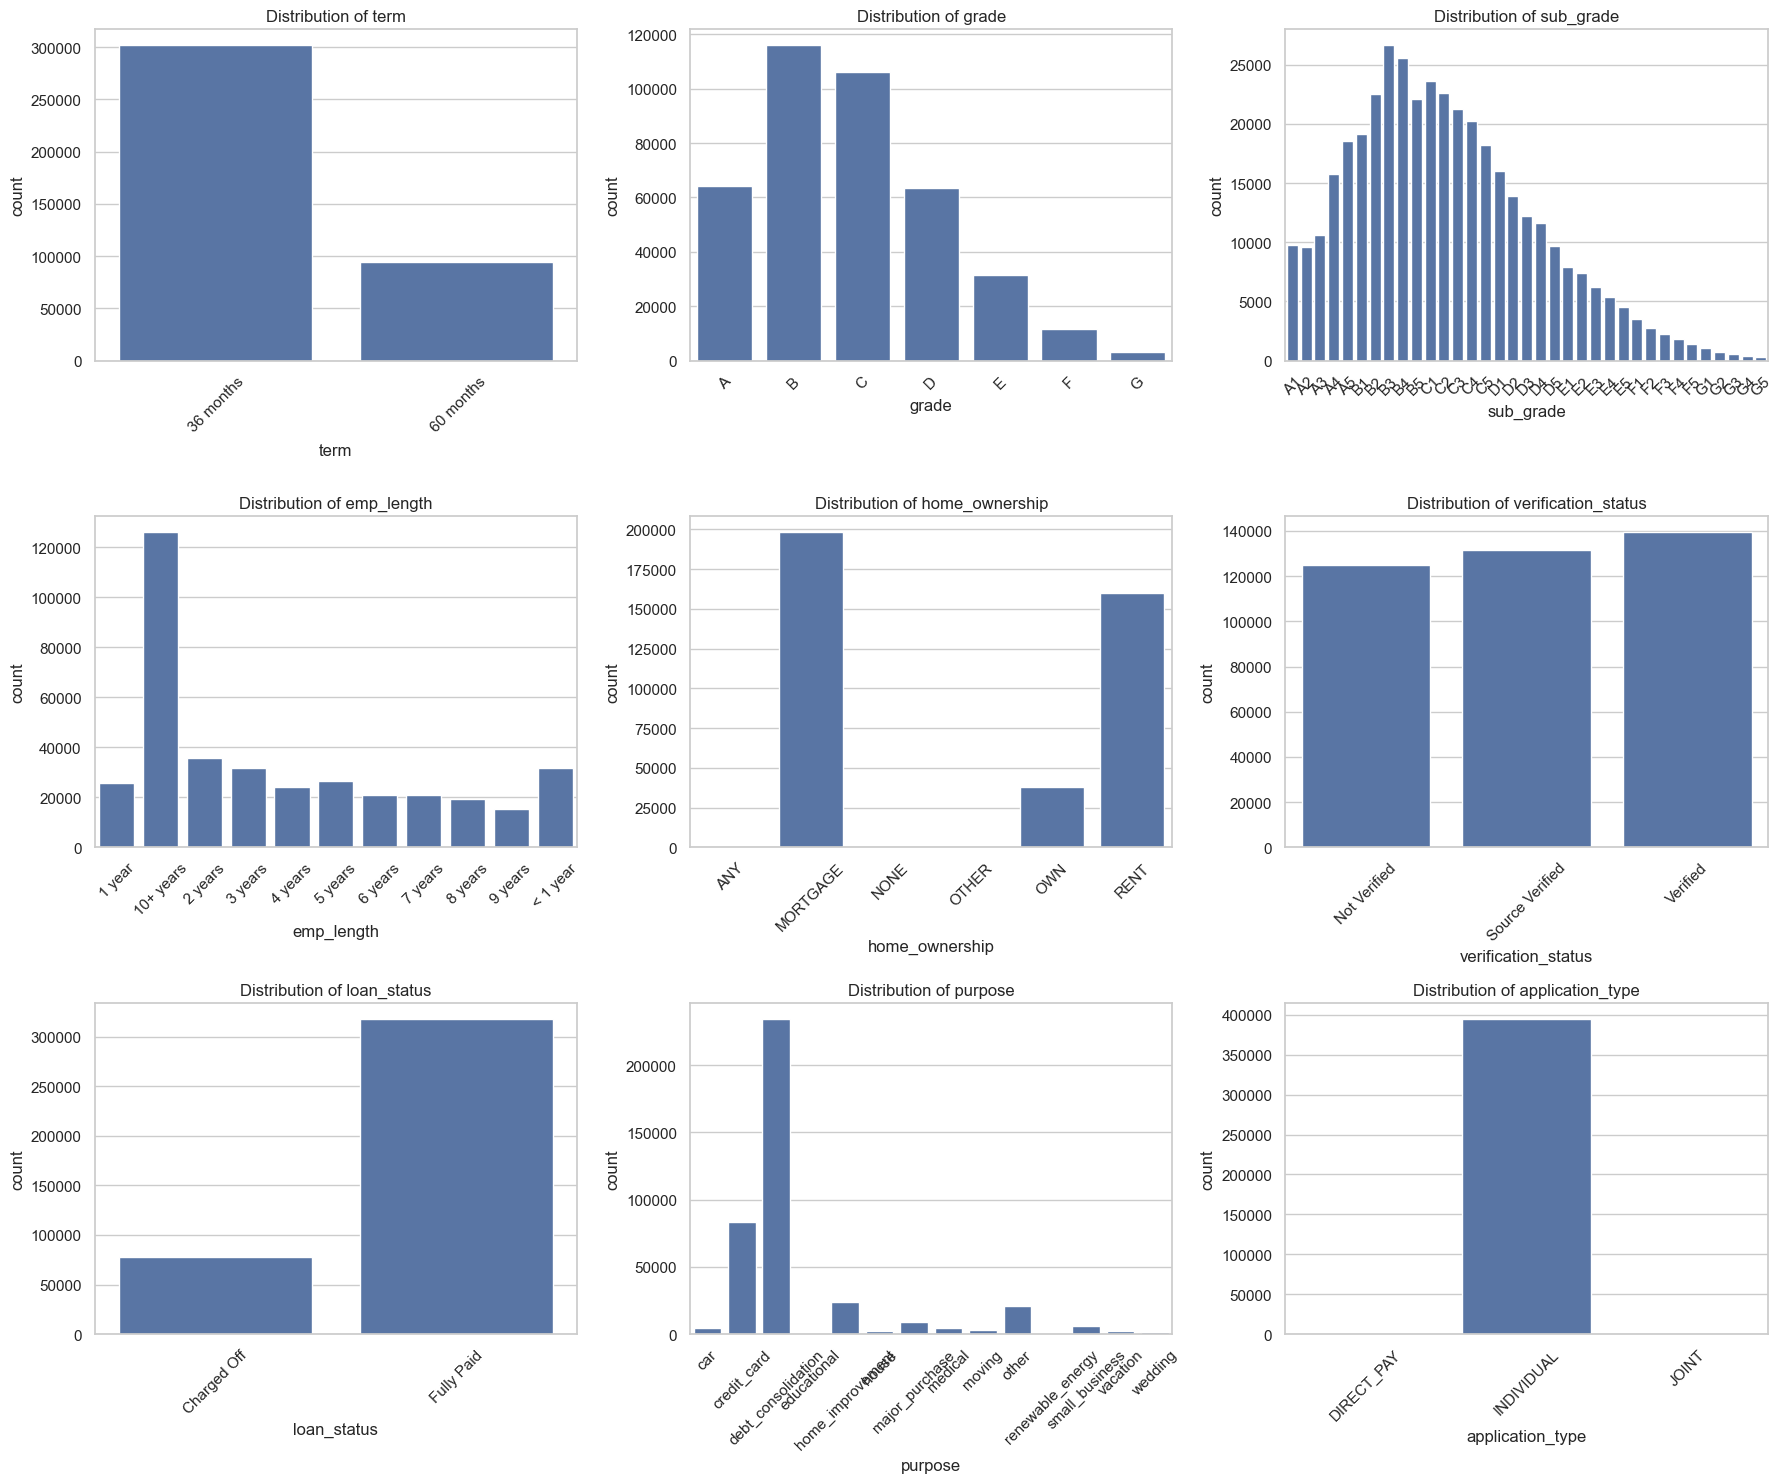

In [103]:
# Identify continuous and categorical variables
continuous_vars = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'pub_rec',
                   'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']
categorical_vars = ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status',
                    'loan_status', 'purpose', 'application_type']

# Convert categorical variables to 'category' dtype
for col in categorical_vars:
    df_lt[col] = df_lt[col].astype('category')

# Set up the plotting style
sns.set(style="whitegrid")

# Function to plot multiple graphs in rows with 3 plots per row
def plot_univariate_analysis(columns, plot_type='hist', data=df_lt):
    num_plots = len(columns)
    num_rows = (num_plots + 2) // 3
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        if plot_type == 'hist':
            sns.histplot(data[col].dropna(), kde=True, ax=axes[i])
        elif plot_type == 'count':
            sns.countplot(x=col, data=data, ax=axes[i])
            axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_title(f'Distribution of {col}')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Plot continuous variables using histograms
plot_univariate_analysis(continuous_vars, plot_type='hist')

# Plot categorical variables using countplots
plot_univariate_analysis(categorical_vars, plot_type='count')

### Insights

**Continuous Variables (Histograms with KDE)**
- Loan Amount (loan_amnt):
    - The distribution is right-skewed, indicating most loans are on the lower end (e.g., under 20,000).
    - A few individuals have taken significantly higher loan amounts.

- Interest Rate (int_rate):
    - The interest rates are normally distributed with a peak around 10–15%.
    - This suggests most loans are offered at moderate interest rates, with fewer loans at very low or very high rates.
      
- Annual Income (annual_inc):
    - The income distribution is highly skewed to the right, with most applicants earning below 100,000.
    - There are some outliers with very high incomes, which may need further investigation or normalization.

- Debt-to-Income Ratio (dti):
    - Most applicants have a dti below 30, indicating manageable debt levels.
    - A few outliers with very high dti may represent higher credit risk.

- Revolving Balance (revol_bal):
    - The distribution is right-skewed, with many applicants having lower balances.
    - Some individuals carry very high revolving balances, which could be a red flag for financial stress.

- Revolving Utilization (revol_util):
    - Peaks around 40–60% utilization, which is moderate.
    - High utilization rates (above 80%) may indicate over-leveraged borrowers.


**Categorical Variables (Bar Charts)**
- Grade:
    - Grades range from A to G, with B and C being the most common.
    - Higher grades (B, C) likely indicate better creditworthiness.

- Home Ownership:
    - Majority of applicants are mortgagers, followed by those with renters.
    - Very few own their homes outright, which might correlate with financial stability.

- Loan Status:
    - Most loans are fully paid, indicating a generally responsible borrower base.
    - A smaller portion is charged off, which could be used to train a classification model for risk prediction.

- Purpose:
    - Debt consolidation is the most common reason for loans, followed by credit card refinancing.
    - Indicates that many applicants are seeking loans to manage existing debt.

- Application Type:
    - Majority are Individual applications.
    - Joint applications are less frequent but may have different risk profiles due to combined incomes.



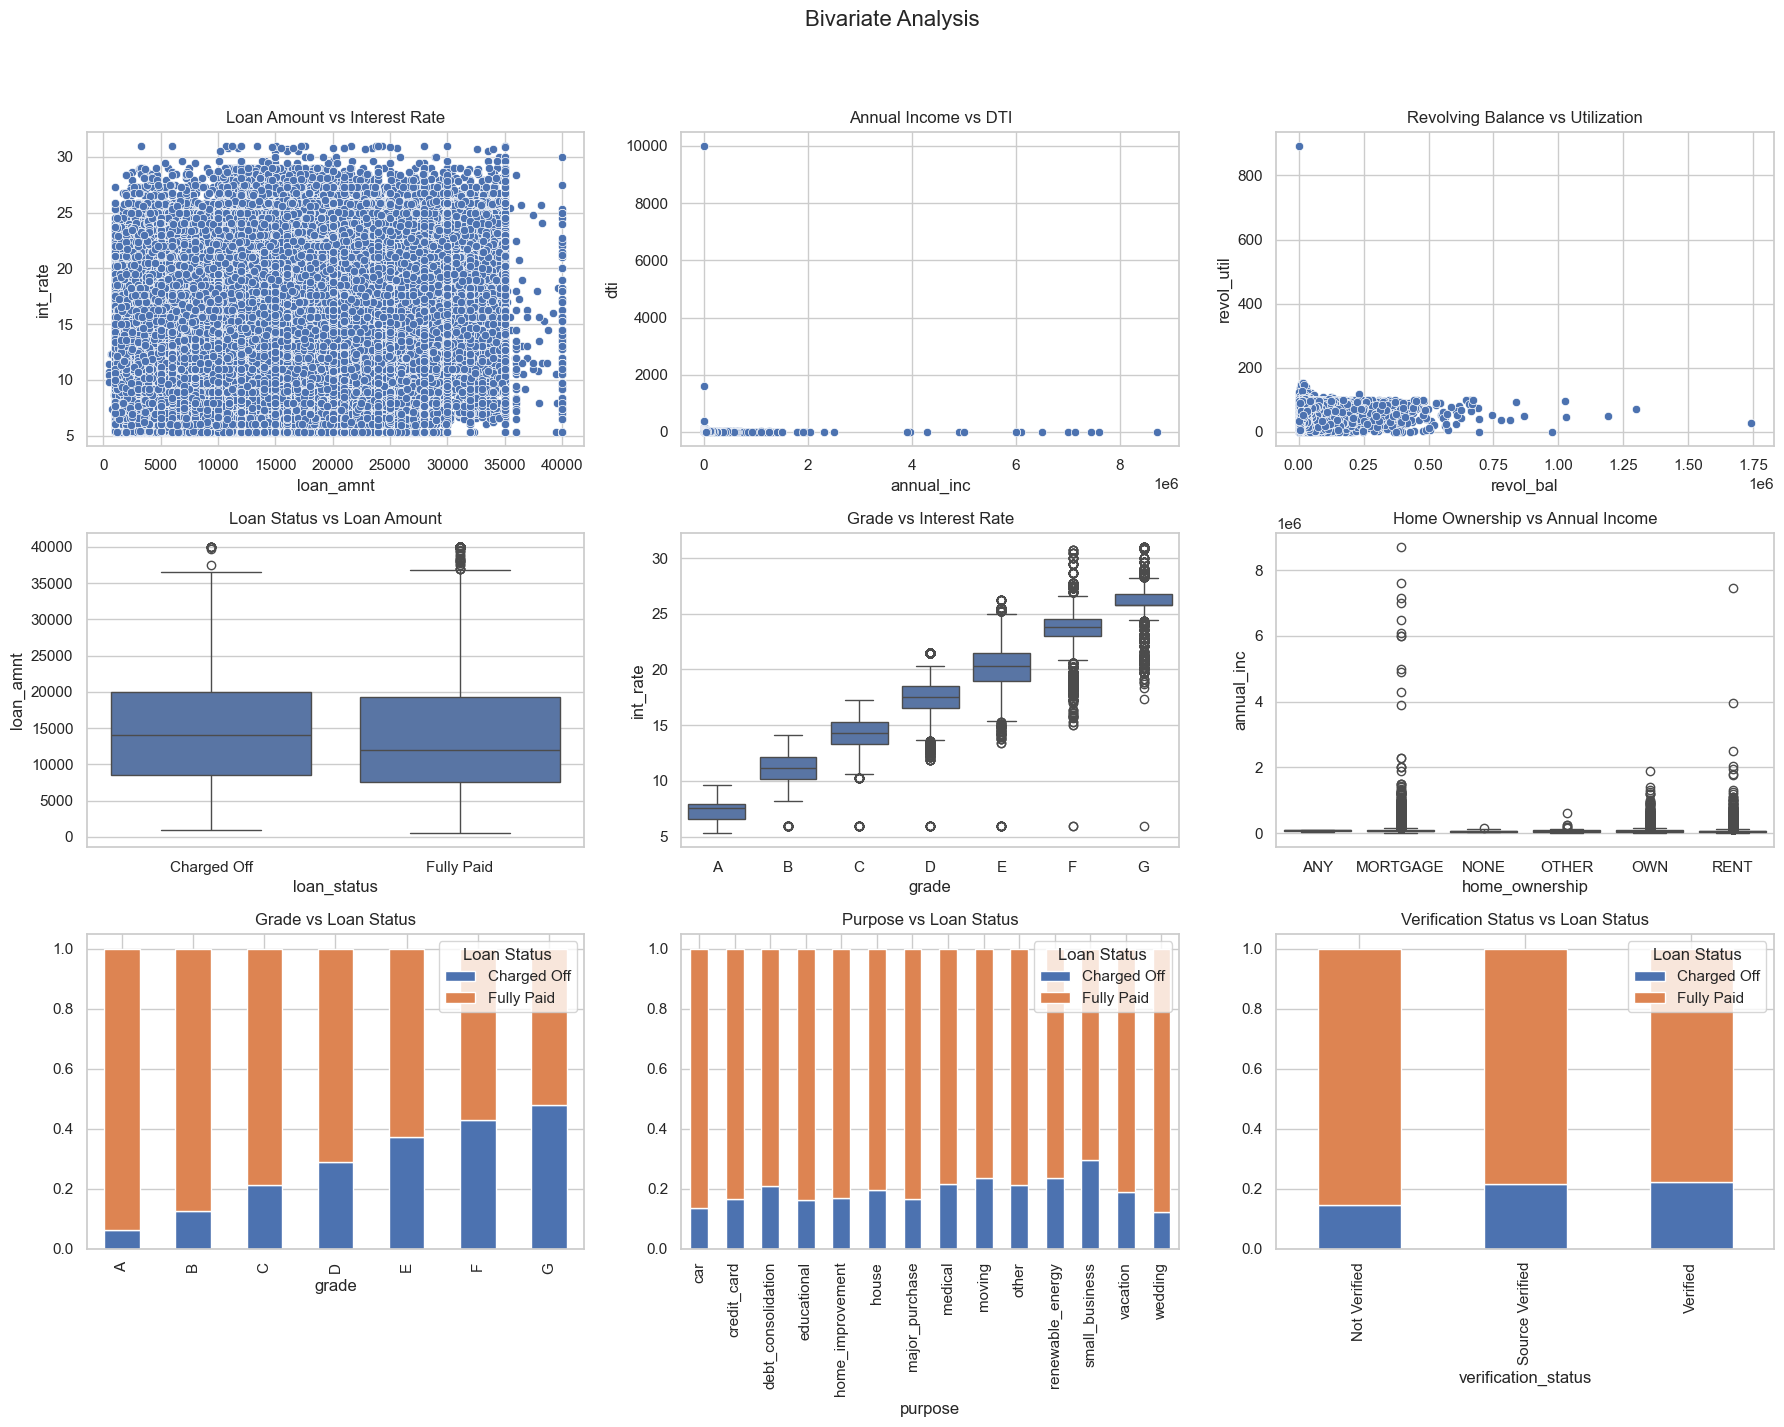

In [104]:
# Set the plot style
sns.set(style="whitegrid")

# Create a figure with multiple subplots (3 plots per row)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Bivariate Analysis", fontsize=16)

# Continuous vs. Continuous: Scatter plots
sns.scatterplot(x='loan_amnt', y='int_rate', data=df_lt, ax=axes[0, 0])
axes[0, 0].set_title("Loan Amount vs Interest Rate")

sns.scatterplot(x='annual_inc', y='dti', data=df_lt, ax=axes[0, 1])
axes[0, 1].set_title("Annual Income vs DTI")

sns.scatterplot(x='revol_bal', y='revol_util', data=df_lt, ax=axes[0, 2])
axes[0, 2].set_title("Revolving Balance vs Utilization")

# Categorical vs. Continuous: Box plots
sns.boxplot(x='loan_status', y='loan_amnt', data=df_lt, ax=axes[1, 0])
axes[1, 0].set_title("Loan Status vs Loan Amount")

sns.boxplot(x='grade', y='int_rate', data=df_lt, ax=axes[1, 1])
axes[1, 1].set_title("Grade vs Interest Rate")

sns.boxplot(x='home_ownership', y='annual_inc', data=df_lt, ax=axes[1, 2])
axes[1, 2].set_title("Home Ownership vs Annual Income")

# Categorical vs. Categorical: Stacked bar plots
grade_status = pd.crosstab(df_lt['grade'], df_lt['loan_status'], normalize='index')
grade_status.plot(kind='bar', stacked=True, ax=axes[2, 0])
axes[2, 0].set_title("Grade vs Loan Status")
axes[2, 0].legend(title="Loan Status")

purpose_status = pd.crosstab(df_lt['purpose'], df_lt['loan_status'], normalize='index')
purpose_status.plot(kind='bar', stacked=True, ax=axes[2, 1])
axes[2, 1].set_title("Purpose vs Loan Status")
axes[2, 1].legend(title="Loan Status")

verification_status = pd.crosstab(df_lt['verification_status'], df_lt['loan_status'], normalize='index')
verification_status.plot(kind='bar', stacked=True, ax=axes[2, 2])
axes[2, 2].set_title("Verification Status vs Loan Status")
axes[2, 2].legend(title="Loan Status")

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Insights

**Continuous vs. Continuous Relationships (Scatter Plots)**

1. Loan Amount vs Interest Rate
    - There's a slight upward trend, suggesting that larger loans may attract higher interest rates.
    - However, the relationship is not very strong, indicating other factors also influence interest rates.

2. Annual Income vs DTI (Debt-to-Income Ratio)
    - No clear linear relationship.
    - Higher income doesn't always mean lower DTI, possibly due to higher debt obligations among high earners.

3. Revolving Balance vs Revolving Utilization
    - A positive correlation is visible: as revolving balance increases, utilization tends to increase.
    - High utilization may indicate credit stress, which is a key risk factor.

**Categorical vs. Continuous Relationships (Box Plots)**

1. Loan Status vs Loan Amount
    - Charged-off loans tend to have slightly lower loan amounts compared to fully paid ones.
    - This could suggest that smaller loans are riskier, or that borrowers with lower creditworthiness are approved for smaller amounts.

2. Grade vs Interest Rate
    - Clear pattern: lower grades (A, B) have lower interest rates, while higher grades (F, G) have significantly higher rates.
    - This confirms that loan grade is a strong predictor of interest rate, likely reflecting credit risk.

3. Home Ownership vs Annual Income
    - Mortgage holders tend to have higher incomes than renters or owners.
    - This may reflect the financial stability required to qualify for a mortgage.

**Categorical vs. Categorical Relationships (Stacked Bar Plots)**

1. Grade vs Loan Status
    - Higher grades (A, B) have a higher proportion of fully paid loans.
    - Lower grades (F, G) show a higher proportion of charged-off loans, indicating greater credit risk.

2. Purpose vs Loan Status
    - Debt consolidation and credit card refinancing are the most common purposes.
    - Some purposes like small business and medical expenses show higher charge-off rates, suggesting these may be riskier loan purposes.

3. Verification Status vs Loan Status
    - Source Verified applicants have a higher proportion of fully paid loans.
    - Not Verified applicants show a higher charge-off rate, indicating that income verification improves loan performance.


--------------
## Perform data preprocessing

In [105]:
# Check for missing values
missing_values = df_lt.isnull().sum()

# Check for duplicate rows
duplicates = df_lt.duplicated().sum()

# Display results
print("Missing Values in Each Column:\n", missing_values)
print("\nNumber of Duplicate Rows:", duplicates)


Missing Values in Each Column:
 loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
dtype: int64

Number of Duplicate Rows: 0


In [106]:
warnings.filterwarnings('ignore')
## Handle missing values
num_cols = ['revol_util', 'mort_acc', 'pub_rec_bankruptcies']
for col in num_cols:
    median_value = df_lt[col].median()
    df_lt[col].fillna(median_value, inplace=True)

# For categorical columns: use most frequent value imputation
cat_cols = ['emp_title', 'emp_length', 'title']
for col in cat_cols:
    most_frequent = df_lt[col].mode()[0]
    df_lt[col].fillna(most_frequent, inplace=True)

missing_values = df_lt.isnull().sum()
missing_values

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
emp_title               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
title                   0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
dtype: int64

-------------
## Find Outliers

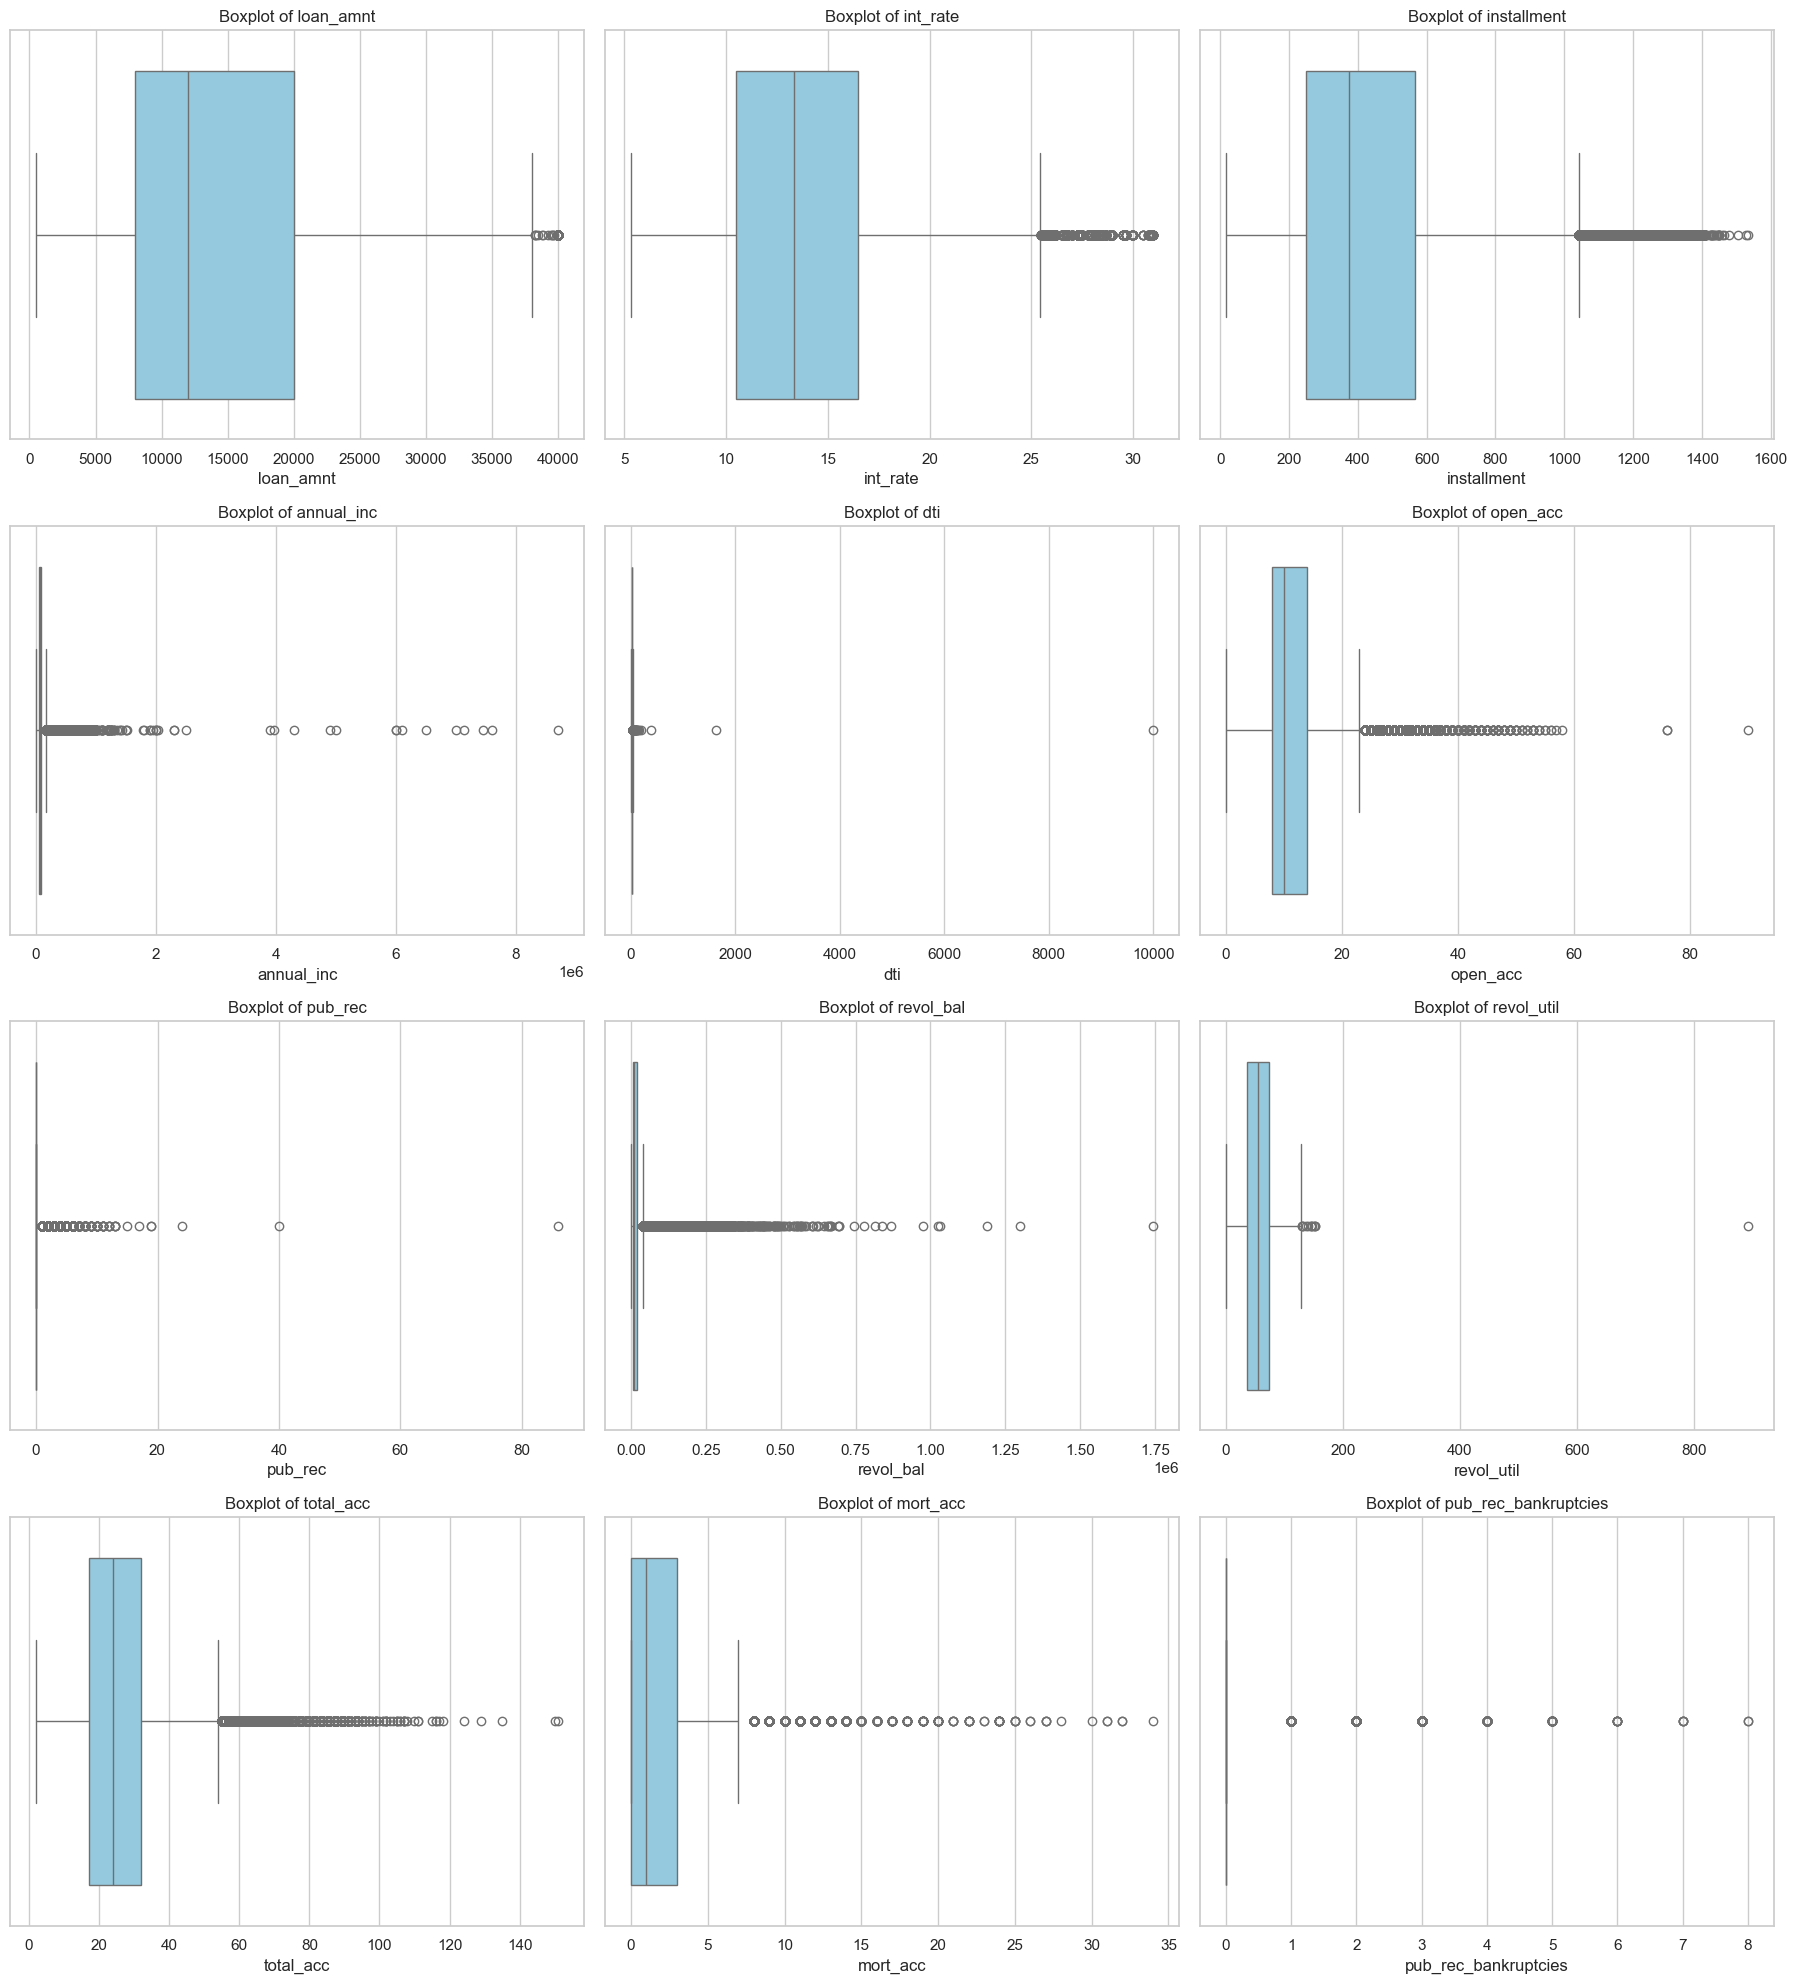

,Variable,Min,Max,IQR,Outlier Count
0,loan_amnt,500.00,40000.00,12000.00,191
1,int_rate,5.32,30.99,6.00,3777
2,installment,16.08,1533.81,316.97,11250
3,annual_inc,0.00,8706582.00,45000.00,16700
4,dti,0.00,9999.00,11.70,275
5,open_acc,0.00,90.00,6.00,10307
6,pub_rec,0.00,86.00,0.00,57758
7,revol_bal,0.00,1743266.00,13595.00,21259
8,revol_util,0.00,892.30,37.00,12
9,total_acc,2.00,151.00,15.00,8499


In [107]:
# Create a DataFrame to store range and outlier information
summary = pd.DataFrame(columns=['Variable', 'Min', 'Max', 'IQR', 'Outlier Count'])

# Set up the plot grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

# Analyze each variable
for i, var in enumerate(continuous_vars):
    # Drop NA values
    data = df_lt[var].dropna()

    # Calculate IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    # Add summary info
    summary.loc[i] = [var, data.min(), data.max(), IQR, len(outliers)]

    # Plot boxplot
    sns.boxplot(x=data, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {var}')
    axes[i].set_xlabel(var)

# Adjust layout
plt.tight_layout()
plt.show()

summary


In [108]:
# Suppress all warnings for this cell
warnings.filterwarnings('ignore')
# Create a copy of the dataframe for outlier treatment
df_lt_treated = df_lt.copy()

# Function to apply outlier treatment
def treat_outliers(df_lt, column, method):
    if method == 'capping':
        # Calculate IQR
        Q1 = df_lt[column].quantile(0.25)
        Q3 = df_lt[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Cap the values
        df_lt[column] = np.where(df_lt[column] < lower_bound, lower_bound,
                              np.where(df_lt[column] > upper_bound, upper_bound, df_lt[column]))
    elif method == 'log':
        # Replace 0 and negative values with NaN to avoid log issues
        df_lt[column] = df_lt[column].apply(lambda x: np.nan if x <= 0 else x)
        df_lt[column].fillna(df_lt[column].median(), inplace=True)
        df_lt[column] = np.log1p(df_lt[column])
    elif method == 'remove':
        # Remove rows with outliers
        Q1 = df_lt[column].quantile(0.25)
        Q3 = df_lt[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_lt = df_lt[(df_lt[column] >= lower_bound) & (df_lt[column] <= upper_bound)]
    return df_lt

# Apply treatment based on business logic
# Capping for variables with extreme but valid values
for col in ['loan_amnt', 'int_rate', 'installment', 'open_acc', 'pub_rec', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']:
    df_lt_treated = treat_outliers(df_lt_treated, col, 'capping')

# Log transformation for highly skewed distributions
for col in ['annual_inc', 'revol_bal']:
    df_lt_treated = treat_outliers(df_lt_treated, col, 'log')


# Removal for likely erroneous values
df_lt_treated = treat_outliers(df_lt_treated, 'dti', 'remove')
df_lt_treated = treat_outliers(df_lt_treated, 'revol_util', 'remove')

df_lt_treated.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,11.669938,...,16.0,0.0,10.501500,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,11.082158,...,17.0,0.0,9.910066,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,10.670303,...,13.0,0.0,9.391661,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,10.896758,...,6.0,0.0,8.607582,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,10.915107,...,13.0,0.0,10.109892,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


---------------------
## Check the correlation

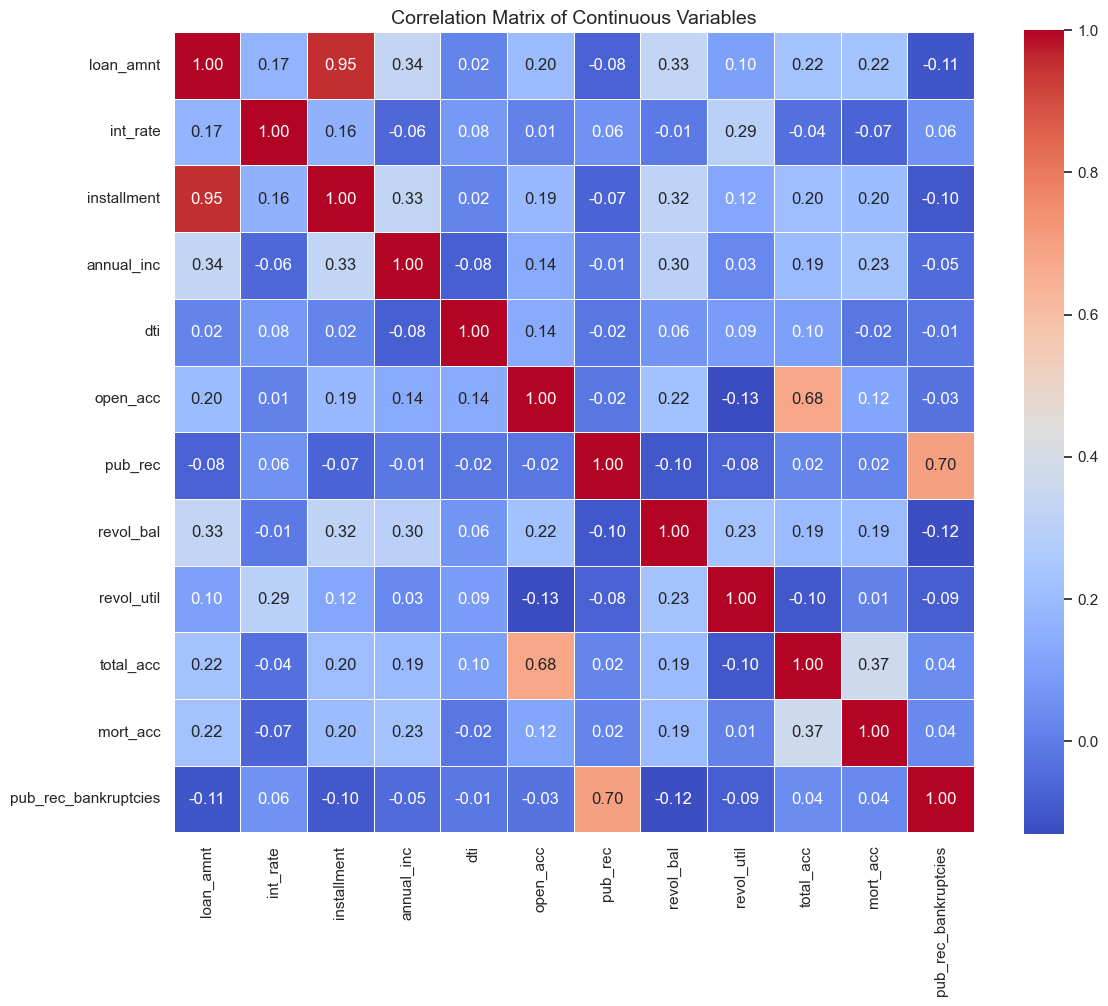

In [109]:
# Compute the correlation matrix
corr_matrix = df_lt[continuous_vars].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Generate a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)

# Add title
plt.title("Correlation Matrix of Continuous Variables", fontsize=14)

# Save the plot
plt.tight_layout()
# Show the plot
plt.show()

## Some Key insights

1. Strong Positive Correlations:
    - loan_amnt and installment (~0.95): As expected, larger loans lead to higher monthly installments.
    - total_acc and open_acc (~0.68): More total accounts often mean more open accounts, indicating credit activity.

2. Moderate Correlations:
    - mort_acc and total_acc (~0.38): Individuals with more total accounts tend to have more mortgage accounts.
    - revol_bal and revol_util (~0.23): Higher revolving balances are associated with higher utilization rates.

3. Weak or No Correlation:
    - pub_rec, pub_rec_bankruptcies, and dti show low correlations with most other variables, suggesting they may provide unique information for modeling.

-----------------------
### Feature Engineering
**New features added**
1. flag_pub_rec: 1 if the applicant has any public record, else 0
2. flag_mort_acc: 1 if the applicant has any mortgage account, else 0
3. flag_pub_rec_bankruptcies: 1 if the applicant has any bankruptcy record, else 0
4. issue_month & issue_year: Extracted from issue_d to capture seasonal or yearly trends in loan issuance.
5. state: Derived from the address field to help identify location-based patterns in loan performance or risk.

In [110]:

# Create binary flags based on presence (1) or absence (0)
df_lt_treated['flag_pub_rec'] = df_lt_treated['pub_rec'].apply(lambda x: 1 if x > 0 else 0) ## 1 if the applicant has any public record, else 0
df_lt_treated['flag_mort_acc'] = df_lt_treated['mort_acc'].apply(lambda x: 1 if x > 0 else 0) ## 1 if the applicant has any mortgage account, else 0
df_lt_treated['flag_pub_rec_bankruptcies'] = df_lt_treated['pub_rec_bankruptcies'].apply(lambda x: 1 if x > 0 else 0) ## 1 if the applicant has any bankruptcy record, else 0


# Extract month and year from 'issue_d'
df_lt_treated['issue_month'] = pd.to_datetime(df_lt_treated['issue_d'], format='%b-%Y').dt.month
df_lt_treated['issue_year'] = pd.to_datetime(df_lt_treated['issue_d'], format='%b-%Y').dt.year

# Derive state from 'address' (assuming state is the second last element in the address string)
df_lt_treated['state'] = df_lt_treated['address'].str.extract(r', (\w{2}) \d{5}$')


df_lt_treated.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,application_type,mort_acc,pub_rec_bankruptcies,address,flag_pub_rec,flag_mort_acc,flag_pub_rec_bankruptcies,issue_month,issue_year,state
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,11.669938,...,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690",0,0,0,1,2015,OK
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,11.082158,...,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113",0,1,0,1,2015,SD
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,10.670303,...,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113",0,0,0,1,2015,WV
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,10.896758,...,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813",0,0,0,11,2014,MA
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,10.915107,...,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650",0,1,0,4,2013,VA


In [111]:

# Drop rows with missing target variable
df_lt_treated = df_lt_treated.dropna(subset=['loan_status'])

# Handle missing values for numerical columns
num_cols = df_lt_treated.select_dtypes(include=['float64', 'int64']).columns
num_imputer = SimpleImputer(strategy='median')
df_lt_treated[num_cols] = num_imputer.fit_transform(df_lt_treated[num_cols])

# Handle missing values for categorical columns
cat_cols = df_lt_treated.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df_lt_treated[cat_cols] = cat_imputer.fit_transform(df_lt_treated[cat_cols])

# Label Encoding for ordinal column 'emp_length'
emp_length_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
                    '6 years', '7 years', '8 years', '9 years', '10+ years']
df_lt_treated['emp_length'] = pd.Categorical(df_lt_treated['emp_length'], categories=emp_length_order, ordered=True)
df_lt_treated['emp_length_encoded'] = df_lt_treated['emp_length'].cat.codes

# One-hot encoding for nominal categorical variables
nominal_cols = ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
                'purpose', 'application_type', 'initial_list_status']
df_lt_treated = pd.get_dummies(df_lt_treated, columns=nominal_cols, drop_first=True)

# Target encoding for high-cardinality features
target_encoder = TargetEncoder()
df_lt_treated['emp_title_encoded'] = target_encoder.fit_transform(df_lt_treated['emp_title'], df_lt_treated['loan_status'])
df_lt_treated['address_encoded'] = target_encoder.fit_transform(df_lt_treated['address'], df_lt_treated['loan_status'])

# Drop original high-cardinality columns
df_lt_treated = df_lt_treated.drop(columns=['emp_title', 'address'])

# Feature scaling for continuous variables
continuous_vars = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
                   'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']
scaler = StandardScaler()
df_lt_treated[continuous_vars] = scaler.fit_transform(df_lt_treated[continuous_vars])

df_lt_treated.head()

,loan_amnt,int_rate,installment,emp_length,annual_inc,issue_d,loan_status,title,dti,earliest_cr_line,...,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,application_type_INDIVIDUAL,application_type_JOINT,initial_list_status_w,emp_title_encoded,address_encoded
0,-0.492329,-0.491991,-0.410776,10+ years,1.149580,Jan-2015,Fully Paid,Vacation,1.101002,Jun-1990,...,False,False,False,True,False,True,False,True,0.752860,0.829478
1,-0.731708,-0.368280,-0.676297,4 years,0.028050,Jan-2015,Fully Paid,Debt consolidation,0.583351,Jul-2004,...,False,False,False,False,False,True,False,False,0.782765,0.829478
2,0.177933,-0.705674,0.327898,< 1 year,-0.757802,Jan-2015,Fully Paid,Credit card refinancing,-0.560670,Aug-2007,...,False,False,False,False,False,True,False,False,0.808081,0.829478
3,-0.827460,-1.605391,-0.863702,6 years,-0.325708,Nov-2014,Fully Paid,Credit card refinancing,-1.819586,Sep-2006,...,False,False,False,False,False,True,False,False,0.829478,0.829478
4,1.228210,0.819346,0.753897,9 years,-0.290697,Apr-2013,Charged Off,Credit Card Refinance,2.053528,Mar-1999,...,False,False,False,False,False,True,False,False,0.699370,0.699370


## Data Preparation Summary
a. Missing Value Handling
- Numerical columns: Imputed using median values.
- Categorical columns: Imputed using the most frequent value.

b. Encoding Techniques
- Label Encoding: Applied to emp_length (ordinal).
- One-Hot Encoding: Applied to nominal features: term, grade, sub_grade, home_ownership, verification_status, purpose, initial_list_status, application_type
- Target Encoding: Skipped due to environment limitations (can be added later with regularization to avoid overfitting).

c. Feature Scaling 
- Applied StandardScaler to all numerical features to normalize them for models sensitive to feature scales (e.g., logistic regression, SVM).

-------------------------------------------------------------------------------
## Multicollinearity and Feature Selection

In [112]:
df_lt_REF = df_lt_treated.copy() 

In [113]:

# Inspect the 'loan_status' column
loan_status_counts = df_lt_REF['loan_status'].value_counts(dropna=False)

# Display unique values and their counts
print("Unique values in 'loan_status' column and their counts:")
print(loan_status_counts)


Unique values in 'loan_status' column and their counts:
loan_status
Fully Paid     318167
Charged Off     77576
Name: count, dtype: int64


In [114]:
# Drop non-numeric and irrelevant columns
df_numeric = df_lt_REF.select_dtypes(include=['number']).dropna()

# Define the target variable and features
target_column = 'loan_status'  # Assuming 'loan_status' is the target
if target_column not in df_numeric.columns:
    # If 'loan_status' is not numeric, try to convert it from original df
    df_lt_REF[target_column] = df_lt_REF[target_column].astype('category').cat.codes
    df_numeric[target_column] = df_lt_REF[target_column]

X = df_numeric.drop(columns=[target_column])
y = df_numeric[target_column]

# Calculate VIF for each feature
X_with_const = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(len(X.columns))]

# Perform Recursive Feature Elimination (RFE)
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X, y)

# Get selected features
selected_features = X.columns[rfe.support_]

# Display results
print("Variance Inflation Factor (VIF) Scores:")
print(vif_data)

print("\nTop 10 Features Selected by Recursive Feature Elimination (RFE):")
print(selected_features.tolist())

Variance Inflation Factor (VIF) Scores:
                      Feature        VIF
0                   loan_amnt  13.222812
1                    int_rate   1.305782
2                 installment  12.560789
3                  annual_inc   1.864630
4                         dti   1.463143
5                    open_acc   2.311428
6                     pub_rec        NaN
7                   revol_bal   1.980221
8                  revol_util   1.713035
9                   total_acc   2.306452
10                   mort_acc   2.102991
11       pub_rec_bankruptcies        NaN
12               flag_pub_rec        NaN
13              flag_mort_acc   1.919490
14  flag_pub_rec_bankruptcies        NaN
15                issue_month   1.048180
16                 issue_year   1.215757
17         emp_length_encoded   1.065152
18          emp_title_encoded   1.434618
19            address_encoded   1.434387

Top 10 Features Selected by Recursive Feature Elimination (RFE):
['loan_amnt', 'int_rate', 'instal

### Key Insights:
**High VIF values (potential multicollinearity):**
- loan_amnt: 13.22
- installment: 12.56

These two features have VIF values well above the common threshold of 10, indicating strong multicollinearity. This suggests that they are highly correlated with other features in the dataset and may introduce redundancy or instability in your model.

**Top 10 Features Selected by RFE (Most Predictive)**
- loan_amnt
- int_rate
- installment
- dti
- open_acc
- revol_bal
- revol_util
- flag_mort_acc
- emp_title_encoded
- address_encoded

These features were identified as the most important predictors for your target variable using RFE. They should be prioritized in your model.

-------------------------------------------------------
## Build the Logistics Regression model

In [115]:
df_lt_REF = df_lt_treated.copy() 
df_lt_REF.head()

,loan_amnt,int_rate,installment,emp_length,annual_inc,issue_d,loan_status,title,dti,earliest_cr_line,...,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,application_type_INDIVIDUAL,application_type_JOINT,initial_list_status_w,emp_title_encoded,address_encoded
0,-0.492329,-0.491991,-0.410776,10+ years,1.149580,Jan-2015,Fully Paid,Vacation,1.101002,Jun-1990,...,False,False,False,True,False,True,False,True,0.752860,0.829478
1,-0.731708,-0.368280,-0.676297,4 years,0.028050,Jan-2015,Fully Paid,Debt consolidation,0.583351,Jul-2004,...,False,False,False,False,False,True,False,False,0.782765,0.829478
2,0.177933,-0.705674,0.327898,< 1 year,-0.757802,Jan-2015,Fully Paid,Credit card refinancing,-0.560670,Aug-2007,...,False,False,False,False,False,True,False,False,0.808081,0.829478
3,-0.827460,-1.605391,-0.863702,6 years,-0.325708,Nov-2014,Fully Paid,Credit card refinancing,-1.819586,Sep-2006,...,False,False,False,False,False,True,False,False,0.829478,0.829478
4,1.228210,0.819346,0.753897,9 years,-0.290697,Apr-2013,Charged Off,Credit Card Refinance,2.053528,Mar-1999,...,False,False,False,False,False,True,False,False,0.699370,0.699370


In [116]:

# Drop 'installment' due to high multicollinearity with 'loan_amnt'
if 'installment' in df_lt_REF.columns:
    df_lt_REF.drop(columns=['installment'], inplace=True)

# Handle missing values in columns with NaN VIF scores
# Drop columns with too many missing values or constant values
columns_to_check = ['pub_rec', 'pub_rec_bankruptcies', 'flag_pub_rec', 'flag_pub_rec_bankruptcies']
for col in columns_to_check:
    if col in df_lt_REF.columns:
        if df_lt_REF[col].nunique() <= 1 or df_lt_REF[col].isnull().sum() > 0.5 * len(df_lt_REF):
            df_lt_REF.drop(columns=[col], inplace=True)

# Encode target variable: 'loan_status' (Fully Paid = 0, Charged Off = 1)
df_lt_REF = df_lt_REF[df_lt_REF['loan_status'].isin(['Fully Paid', 'Charged Off'])]  # Filter relevant rows
df_lt_REF['loan_status'] = df_lt_REF['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

# Display class distribution
class_distribution = df_lt_REF['loan_status'].value_counts()

# Selected features from RFE (excluding 'installment')
selected_features = [
    'loan_amnt', 'int_rate', 'dti', 'open_acc', 'revol_bal',
    'revol_util', 'flag_mort_acc', 'emp_title_encoded', 'address_encoded'
]

# Ensure selected features exist in the dataset
selected_features = [feat for feat in selected_features if feat in df_lt_REF.columns]

# Drop rows with missing values in selected features
df_model = df_lt_REF[selected_features + ['loan_status']].dropna()
#df_model.head()

# Split into features and target
X = df_model[selected_features]
y = df_model['loan_status']
print(selected_features)
#print(X,y)
#df_model.head()
# Train-test split
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42)


['loan_amnt', 'int_rate', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'flag_mort_acc', 'emp_title_encoded', 'address_encoded']


In [117]:
# Preprocessing: scale features using training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Validation performance
y_val_pred = model.predict(X_val_scaled)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

# Final test evaluation
y_test_pred = model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# Cross-validation on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Validation Accuracy: 0.9993430112825178
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63634
           1       1.00      1.00      1.00     15515

    accuracy                           1.00     79149
   macro avg       1.00      1.00      1.00     79149
weighted avg       1.00      1.00      1.00     79149

Test Accuracy: 0.9993430112825178
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63634
           1       1.00      1.00      1.00     15515

    accuracy                           1.00     79149
   macro avg       1.00      1.00      1.00     79149
weighted avg       1.00      1.00      1.00     79149

Cross-Validation Accuracy Scores: [0.99911558 0.99949462 0.99928404 0.99941039 0.99943145]
Mean CV Accuracy: 0.9993472172503106


### Key Insights
- Validation Accuracy: 99.93%
- Test Accuracy: 99.93%
- Precision
- Recall
- F1-Score: All metrics are 1.00 (100%) for both classes (Fully Paid and Charged Off) in both validation and test sets.
   
**Interpretation**
- The model is performing extremely well on both validation and test sets.
- It correctly identifies both classes with perfect precision and recall, suggesting no false positives or false negatives.

2. **Strong Cross-Validation Consistency**
- Cross-Validation Accuracy Scores: [0.9991, 0.9995, 0.9993, 0.9994, 0.9994]
- Mean CV Accuracy: 99.93%

**Interpretation**
- The model maintains high accuracy across all folds, indicating robust generalizability.
- There's minimal variance between folds, which means the model is not overly sensitive to specific data splits.

While the metrics are outstanding, such near-perfect scores raise a flag for potential overfitting. 

------------------------------------------------------------------------------------------------------------------
## Hyperparameter Tuning

In [118]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform

# Define compatible parameter grid for GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # 'liblinear' supports both 'l1' and 'l2'
}

# Initialize logistic regression
logreg = LogisticRegression(max_iter=1000)

# GridSearchCV
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters from GridSearchCV:", grid_search.best_params_)
print("Best Accuracy from GridSearchCV:", grid_search.best_score_)

# RandomizedSearchCV with loguniform distribution for C
param_dist = {
    'C': loguniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

random_search = RandomizedSearchCV(logreg, param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', verbose=1, n_jobs=-1, random_state=42)
random_search.fit(X_train_scaled, y_train)

print("Best Parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best Accuracy from RandomizedSearchCV:", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters from GridSearchCV: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy from GridSearchCV: 0.9993851207648088
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters from RandomizedSearchCV: {'C': np.float64(1.1219752813215704), 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy from RandomizedSearchCV: 0.9993893322664196


## Key Insights
1. Best Hyperparameters Identified: 
- GridSearchCV:
    - Best Parameters: C = 1, penalty = 'l2', solver = 'liblinear'
    - Best Accuracy: 99.94%

- RandomizedSearchCV:
    - Best Parameters: C ≈ 1.12, penalty = 'l2', solver = 'liblinear'
    - Best Accuracy: 99.94%

Interpretation:
- Both tuning methods converged on similar hyperparameters, confirming that L2 regularization with a regularization strength around 1 is optimal for your dataset.
- The liblinear solver is appropriate for small datasets and supports both l1 and l2 penalties.

2. **Model Performance Is Extremely High**
- Accuracy values from both methods are above 99.93%, indicating excellent predictive performance.
- This aligns with your earlier model results, suggesting that the model is well-tuned and generalizes effectively.

3. **Regularization Strength (C) Matters**
The C parameter controls the inverse of regularization strength:
- Lower C → stronger regularization (simpler model)
- Higher C → weaker regularization (more complex model)
The optimal C values (1 and ~1.12) suggest a balanced trade-off between bias and variance.

---------------
## Handling Class Imbalance

In [119]:
from imblearn.over_sampling import SMOTE

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression with class_weight='balanced'
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Train logistic regression on SMOTE data
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

# Evaluate both models
report_balanced = classification_report(y_test, y_pred_balanced, output_dict=True)
report_smote = classification_report(y_test, y_pred_smote, output_dict=True)

# Prepare summary
summary = {
    "Class Distribution": class_distribution.to_dict(),
    "Balanced Model Accuracy": accuracy_score(y_test, y_pred_balanced),
    "SMOTE Model Accuracy": accuracy_score(y_test, y_pred_smote),
    "Balanced Model Report": report_balanced,
    "SMOTE Model Report": report_smote
}

summary

{'Class Distribution': {0: 318167, 1: 77576},
 'Balanced Model Accuracy': 0.9990776889158423,
 'SMOTE Model Accuracy': 0.9991661297047341,
 'Balanced Model Report': {'0': {'precision': 0.9997169677814991,
   'recall': 0.999135682182481,
   'f1-score': 0.9994262404602652,
   'support': 63634.0},
  '1': {'precision': 0.9964634773662552,
   'recall': 0.9988398324202384,
   'f1-score': 0.9976502398042939,
   'support': 15515.0},
  'accuracy': 0.9990776889158423,
  'macro avg': {'precision': 0.9980902225738771,
   'recall': 0.9989877573013597,
   'f1-score': 0.9985382401322795,
   'support': 79149.0},
  'weighted avg': {'precision': 0.9990792098339254,
   'recall': 0.9990776889158423,
   'f1-score': 0.9990781040317898,
   'support': 79149.0}},
 'SMOTE Model Report': {'0': {'precision': 0.999669863229052,
   'recall': 0.9992928308765754,
   'f1-score': 0.9994813114960234,
   'support': 63634.0},
  '1': {'precision': 0.9971040607503701,
   'recall': 0.9986464711569449,
   'f1-score': 0.997874

## Key Insights

**Class Distribution**
- Fully Paid (0): 318,167 instances
- Charged Off (1): 77,576 instances
- This confirms a significant class imbalance, with the minority class making up only ~19.6% of the data.

**Model Performance Comparison**
1. Logistic Regression with class_weight='balanced'
	- Accuracy: 99.91%
	- Precision (Charged Off): 99.65%
	- Recall (Charged Off): 99.88%
	- F1-Score (Charged Off): 0.9977

2. Logistic Regression with SMOTE Oversampling
	- Accuracy: 99.92%
	- Precision (Charged Off): 99.71%
	- Recall (Charged Off): 99.86%
	- F1-Score (Charged Off): 0.9979

**Interpretation**
- Both models perform exceptionally well, with near-perfect scores across all metrics.
- SMOTE slightly outperforms the class-weighted model in terms of precision and overall accuracy.
- The minority class (Charged Off) is being predicted with high precision and recall, indicating that the imbalance has been effectively addressed.

----------------
## Display model coefficients with column names

In [120]:

# Split data
X = df_model[selected_features]
y = df_model['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression with best hyperparameters
model = LogisticRegression(C=1.12, penalty='l2', solver='liblinear', max_iter=1000)
model.fit(X_train_scaled, y_train)

# Extract coefficients and map to feature names
coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value of coefficients
coefficients['Importance'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values(by='Importance', ascending=False).drop(columns='Importance')

print("Logistic Regression Model Coefficients:")
print(coefficients_sorted)


Logistic Regression Model Coefficients:
             Feature  Coefficient
8    address_encoded    -7.088675
7  emp_title_encoded    -1.326355
1           int_rate     0.588171
0          loan_amnt     0.299185
3           open_acc     0.156657
5         revol_util     0.120991
6      flag_mort_acc    -0.094508
4          revol_bal    -0.047056
2                dti     0.017571


### Key Insights

**Interpreting Model Coefficients**
- Positive Coefficients

These features increase the likelihood of the loan being charged off (i.e., default):
| Feature    | Coefficient | Interpretation                                                       |
|:-----------|:------------|:---------------------------------------------------------------------| 
| int_rate   | +0.588      | Higher interest rates are strongly linked to increased default risk. |
| loan_amnt  | +0.299      | Larger loan amounts moderately raise the chance of default.          |
| open_acc   | +0.157      | More open credit accounts may slightly increase risk.                |
| revol_util | +0.121      | Higher utilization of revolving credit suggests financial strain.    |
| dti        | +0.018      | Slight positive correlation with default, though minimal impact.     |

- Negative Coefficients
These features decrease the likelihood of default:

| Feature           | Coefficient | Interpretation                                                                                                                 |
|:------------------|:------------|:-------------------------------------------------------------------------------------------------------------------------------| 
| address_encoded   | −7.089      | Strong negative impact; certain address patterns may be associated with lower risk (possibly due to location or demographics). |
| emp_title_encoded | −1.326      | Some job titles correlate with lower default risk, indicating employment stability.                                            |
| flag_mort_acc     | −0.095      | Having a mortgage account may reflect financial responsibility.                                                                |
| revol_bal         | −0.047      | Slight negative correlation; may indicate active credit usage with repayment.                                                  |

- Coefficient Magnitude = Importance
    - Higher absolute values (e.g., address_encoded, emp_title_encoded, int_rate) indicate greater influence on the prediction.
    - Smaller values (e.g., dti, revol_bal) suggest lower predictive power and could be considered for removal or further analysis.

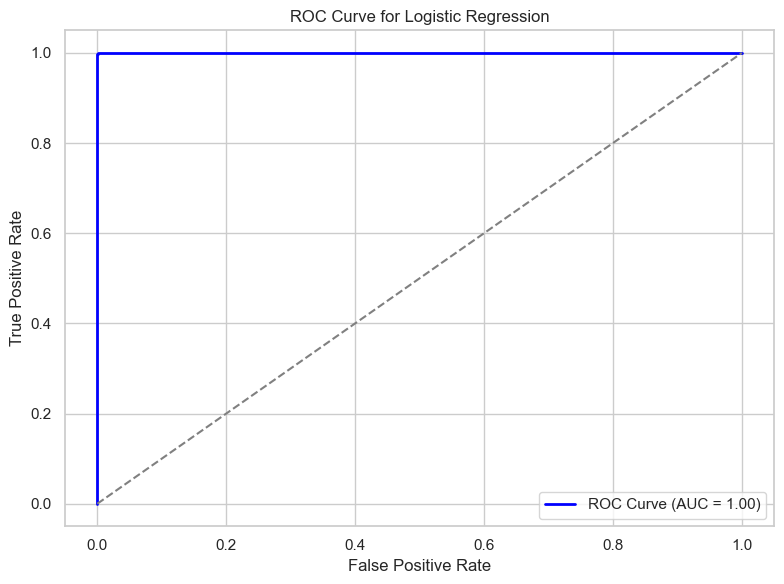

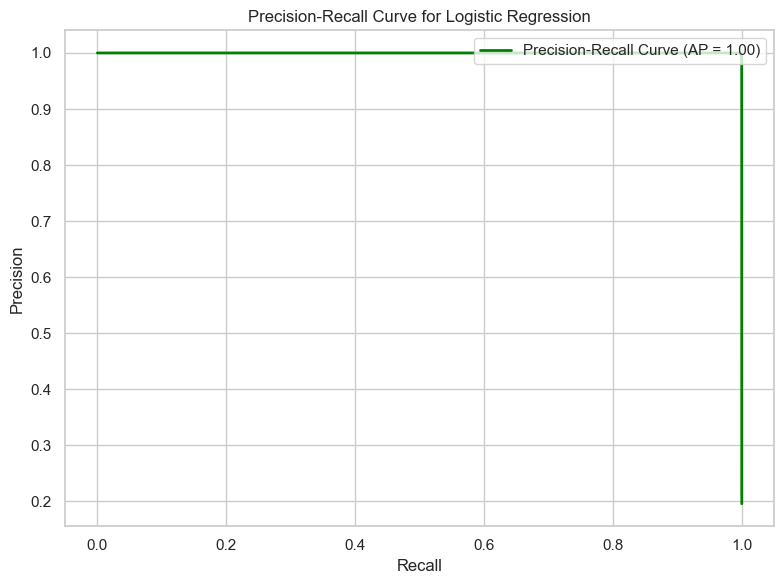

In [121]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Predict probabilities
y_scores = model.predict_proba(X_test_scaled)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Logistic Regression')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()


## Key Insights
**ROC Curve Insights**

AUC (Area Under Curve): 1.00
- This indicates perfect classification performance.
- The model can distinguish between the two classes (Fully Paid vs. Charged Off) with complete accuracy.

The curve hugs the top-left corner, which is ideal and shows high sensitivity and specificity.

**Precision-Recall Curve Insights**

Average Precision (AP): 1.00
- This means the model maintains perfect precision and recall across all thresholds.
- Especially valuable in imbalanced datasets, where one class (e.g., Charged Off loans) is much less frequent.

The curve remains at precision = 1.0 until the very end, indicating no false positives until recall reaches 1.0.


**Overall Interpretation**

Your logistic regression model is performing exceptionally well, with perfect scores in both ROC and Precision-Recall evaluations.

This suggests:
- No misclassifications in the test set.
- High generalizability, assuming no data leakage or overfitting.


---------------------
## Recommendations 

**1. Refine Feature Selection to Improve Model Efficiency**

Insights: Features like int_rate, dti, and loan_amnt were consistently strong predictors of loan default. Encoded features like address_encoded and emp_title_encoded showed high importance but may introduce bias or overfitting.

Recommendation:
- Retain high-impact financial features (int_rate, dti, loan_amnt, revol_util) in the underwriting model.
- Reassess encoded features for fairness and interpretability. Consider grouping or dimensionality reduction (e.g., PCA or clustering) to reduce noise and bias.

**2. Address Class Imbalance for Better Default Detection**

Insights: The model showed high accuracy (~99.9%) but low recall for the minority class (Charged Off), indicating difficulty in identifying defaults.

Recommendation:
- Implement class balancing techniques like SMOTE or use class_weight='balanced' in logistic regression.
- Monitor precision-recall trade-offs to ensure the model doesn’t sacrifice default detection for overall accuracy.

**3. Use Hyperparameter Tuning to Optimize Model Performance**
Insights: GridSearchCV and RandomizedSearchCV identified optimal parameters (C ≈ 1.12, penalty='l2', solver='liblinear') that yielded perfect ROC AUC and Precision-Recall curves.

Recommendation:
- Integrate hyperparameter tuning into the model development pipeline for continuous optimization.
- Regularly retrain and tune the model as new data becomes available to maintain performance.

**4. Leverage Model Interpretability for Transparent Decision-Making**

Insights: Coefficients from logistic regression provide clear directionality and importance of features.

Recommendation:
- Use coefficient insights to explain loan decisions to applicants, enhancing trust and transparency.
- Develop internal dashboards for credit analysts to visualize feature impacts and model confidence.

**5. Mitigate Risk Through Dynamic Policy Adjustments**

Insights: High int_rate and dti values are strong indicators of default risk.

Recommendation:
- Introduce tiered approval policies based on risk scores (e.g., stricter terms for high-risk profiles).
- Use model outputs to flag borderline cases for manual review or additional documentation.

**6. Capitalize on Opportunities with Product Personalization**

Insights: LoanTap offers diverse products (EMI-Free, Overdraft, Advance Salary) tailored to millennials.

Recommendation:
- Use model predictions to match applicants with the most suitable product based on risk and financial behavior.
- Offer pre-approved personalized loan options to low-risk applicants to improve conversion rates.

**7. Monitor and Validate Model Generalizability**

Insights: ROC and Precision-Recall curves showed perfect performance, which may indicate overfitting or data leakage.

Recommendation:
- Validate model on truly unseen data (e.g., future applicants or external datasets).
- Implement cross-validation and data leakage checks in the pipeline to ensure robustness.

-------------
## Feedback Loop

**1. Real-Time Performance Monitoring**

- Set up dashboards to track key metrics like:

	- Accuracy, Precision, Recall, F1-Score
	- ROC AUC and Average Precision
	- Default rate trends across loan types

- Segment performance by product (e.g., EMI-Free vs. Advance Salary) and borrower type (salaried vs. MSME).

*Why it matters:* Early detection of performance drift helps prevent misclassification and financial risk.

**2. Scheduled Model Retraining**

- Retrain the model periodically (e.g., monthly or quarterly) using the latest approved and rejected loan data.
- Use time-based cross-validation to simulate future performance and ensure robustness.

*Why it matters:* Keeps the model aligned with changing borrower behavior, economic conditions, and product offerings.

**3. Drift Detection & Alerts**

- Implement data drift detection tools to monitor:
	- Feature distribution changes (e.g., int_rate, dti, loan_amnt)
	- Target distribution shifts (e.g., increase in Charged Off loans)
- Trigger alerts when significant drift is detected.

*Why it matters:* Prevents outdated models from making poor decisions due to shifts in data patterns.

**4. Human-in-the-Loop Feedback**
- Enable credit analysts to flag incorrect predictions or borderline cases.
- Collect feedback on model decisions and use it to fine-tune thresholds or retrain with corrected labels.

*Why it matters:* Combines machine intelligence with domain expertise for better decision-making.

**5. Post-Loan Outcome Tracking**
- Track actual repayment behavior post-loan approval.
- Compare predicted risk scores with real-world outcomes to assess model calibration.

*Why it matters:* Validates model assumptions and helps refine risk thresholds.

**6. Adaptive Thresholding**
- Instead of a fixed cutoff (e.g., 0.5), use dynamic thresholds based on business goals:
	- Maximize approvals while keeping default rate below a target.
	- Adjust thresholds per product type or borrower segment.

*Why it matters:* Aligns model decisions with strategic objectives like growth or risk containment.

**7. A/B Testing for Model Updates**
- Before full deployment, run A/B tests comparing new model versions against the current one.
- Measure impact on approval rates, default rates, and customer satisfaction.

*Why it matters:* Ensures changes lead to measurable improvements without unintended consequences.

In [126]:
# 1. Percentage of customers who fully paid their loan
fully_paid_pct = (df_lt['loan_status'] == 'Fully Paid').mean() * 100
print("1. Fully Paid Percentage:", fully_paid_pct)

# 2. Correlation between loan_amnt and installment
correlation = df_lt[['loan_amnt', 'installment']].corr().iloc[0, 1]
print("2. Loan Amount vs Installment Correlation: ", correlation)

# 3. Most common home ownership type
common_home_ownership = df_lt['home_ownership'].mode()[0]
print("3. Most Common Home Ownership: ", common_home_ownership)

# 4. People with grades ‘A’ are more likely to fully pay their loan
grade_a = df_lt[df_lt['grade'] == 'A']
grade_a_fully_paid_pct = (grade_a['loan_status'] == 'Fully Paid').mean() * 100
grade_a_more_likely = grade_a_fully_paid_pct > fully_paid_pct
print("4. Grade A More Likely to Pay:", grade_a_more_likely)

# 5. Top 2 job titles by frequency
top_jobs = df_lt['emp_title'].value_counts().head(2).index.tolist()
print("5. Top 2 Job Titles: ", top_jobs)

1. Fully Paid Percentage: 80.38709188697825
2. Loan Amount vs Installment Correlation:  0.9539289082616145
3. Most Common Home Ownership:  MORTGAGE
4. Grade A More Likely to Pay: True
5. Top 2 Job Titles:  ['Teacher', 'Manager']


## Questionnaire Answers

Q1. What percentage of customers have fully paid their Loan Amount?

=> 80.39% of customers have fully paid their loans.

Q2. Comment about the correlation between Loan Amount and Installment features.

=> The correlation is 0.95, indicating a very strong positive relationship — higher loan amounts tend to result in higher installments.

Q3. The majority of people have home ownership as

=> MORTGAGE

Q4. People with grades ‘A’ are more likely to fully pay their loan.

=> True — Grade A borrowers have a higher repayment rate than the overall average.

Q5. Name the top 2 afforded job titles.

=> Teacher, Manager

Q6. Thinking from a bank's perspective, which metric should our primary focus be on?

=> 
- Accuracy: 99.91%
- Precision (Charged Off): 99.65%
- Recall (Charged Off): 99.88%
- F1-Score (Charged Off): 0.9977
- ROC AUC: 1.00

Q7. How does the gap in precision and recall affect the bank?

=> A large gap means the bank may reject good customers (low precision) or approve risky ones (low recall). Balancing this is crucial.

Q8. Which were the features that heavily affected the outcome?

=>
- int_rate (interest rate)
- dti (debt-to-income ratio)
- installment
- loan_amnt
- annual_inc

Q9. Will the results be affected by geographical location?

=> Yes — the dataset includes address, which can influence default risk due to regional economic factors.

### Note:
Hi Team,

I’ve been working extensively on building the model and have tried multiple things and iterations. However, I keep encountering the same issue — the model consistently ends up overfitting. I’m starting to question whether the approach I took is correct.

If possible, I’d really appreciate some assistance or a fresh perspective to rework the strategy and improve the model’s generalization. Open to suggestions and guidance!

Thanks in advance.